# Нейросеть для предсказания калорийности блюд

## Студент - Сайгушев Дамир Даниярович. НИЯУ МИФИ.

## Оглавление

1. Описание задачи
2. Исследовательский анализ данных (EDA)
3. Подготовка данных для обучения
4. Конфигурация модели
5. Архитектура модели
6. Обучение модели
7. Оценка качества модели
8. Анализ ошибок
9. Итоговый вывод

## 1. Описание задачи

Цель проекта — обучить модель, которая будет предсказывать калориийность блюда по его фотографии и списку иннгредиентов.

Это задача регрессии. В качестве основной метрики будем юзать MAE.

## 2. Исследовательский анализ данных (EDA)

Сначала загрузим данные и посмотрим на их структуру.

* простите, но ваш wget req.txt не работал(((

In [91]:
import os
import random
from functools import partial
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer

In [58]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [59]:
DATA_DIR = "data"
IMAGES_DIR = os.path.join(DATA_DIR, "images")

dish_df = pd.read_csv(os.path.join(DATA_DIR, "dish.csv"))
ingredients_df = pd.read_csv(os.path.join(DATA_DIR, "ingredients.csv"))

In [60]:
print("Количество блюд:", len(dish_df))
print("Количество ингредиентов:", len(ingredients_df))

Количество блюд: 3262
Количество ингредиентов: 555


In [61]:
display(dish_df.head())
display(ingredients_df.head())

,dish_id,total_calories,total_mass,ingredients,split
0,dish_1561662216,300.794281,193.0,ingr_0000000508;ingr_0000000122;ingr_000000002...,test
1,dish_1561662054,419.438782,292.0,ingr_0000000312;ingr_0000000026;ingr_000000002...,train
2,dish_1562008979,382.936646,290.0,ingr_0000000448;ingr_0000000520;ingr_000000046...,test
3,dish_1560455030,20.590000,103.0,ingr_0000000471;ingr_0000000031;ingr_0000000347,train
4,dish_1558372433,74.360001,143.0,ingr_0000000453,train


,id,ingr
0,1,cottage cheese
1,2,strawberries
2,3,garden salad
3,4,bacon
4,5,potatoes


Таблица блюд содержит информацию о: идентификатор блюда, его калорийность, массу, список ингредиентов и принадлежность к обучпающей или тестовой выборке.

А total_caloriees целевая переменная, которую в дальнейшем будет предсказывать модель.

В столбце ingredients пока находятся идентификаторы ингредиентов, которые я не особо понимаю, но в Практикуме Вы писали, что это - список всех айдишников ингредиентов в формате. Таблица ингредиентов содержит видимо расшифровку, где каждому ID соответствует реальное название продукта. 

Позже, будет логиченым и простым для работы, заменить технические идентификаторы на нормальные и человечные названия ингредиентов, чтобы использовать их как текстовый вход модели.

Посмотрим на типы данных, количество заполненных значений и проверим наличие пропусков и дубликатов.

In [62]:
dish_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3262 entries, 0 to 3261
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dish_id         3262 non-null   str    
 1   total_calories  3262 non-null   float64
 2   total_mass      3262 non-null   float64
 3   ingredients     3262 non-null   str    
 4   split           3262 non-null   str    
dtypes: float64(2), str(3)
memory usage: 127.6 KB


In [63]:
ingredients_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      555 non-null    int64
 1   ingr    555 non-null    str  
dtypes: int64(1), str(1)
memory usage: 8.8 KB


Слава богу! В обеих таблицах пропущенных значений нет. Не придётся тратить время на это))).

Числовые признаки `total_calories` и `total_mass` имеют тип float, остальные данные в таблице блюд представлены строками. В таблице ингрендиентов идентификатор является целым числом, а название ингредиента — строкой. Так как, типы данных семанттически схожи с тем, что мы ожидали, то и их трогать мы не будем, пожалуй.

Теперь проверим наличие дубликатов и посмотрим на распределение объектов между обучающей и тестовой выборками.

In [64]:
print("Дубликаты в dish_df:", dish_df.duplicated().sum())
print("Дубликаты в ingredients_df:", ingredients_df.duplicated().sum())

print("\nРаспределение по выборкам:")
print(dish_df["split"].value_counts())

Дубликаты в dish_df: 0
Дубликаты в ingredients_df: 0

Распределение по выборкам:
split
train    2755
test      507
Name: count, dtype: int64


Очень хороший датасет, полных дубликатов в таблицах нет!

Данные уже разделены на обучающую и тестовую выборки, при чём пропорции мне интутитивно нравятся. Я дальше и буду использовать именно такую выборку, но только разве что ещё добавим validation


Посмотрим на основные статистики калорийности и массы блюд. Это поможет понять диапазон значений и увидеть возможные выбросы

In [65]:
dish_df[["total_calories", "total_mass"]].describe()

,total_calories,total_mass
count,3262.000000,3262.000000
mean,255.012738,214.980074
std,219.637570,161.497428
min,0.000000,1.000000
25%,80.114996,92.000000
50%,209.110062,177.000000
75%,375.122963,305.000000
max,3943.325195,3051.000000


Ухх, здесь уже появляются первые трудности.

Средняя калл блюда составляет ~ 255 калл, а медианная ~ 209 калл. 

Средняя масса блюда ~ около 215 г, медианная ~ 177 г.

При этом макс значения заметно выше основной части данных. Макс калл достигает 3943, а масса 3051 г. Также встречаются блюда с нулевой калорийностью. Очень похоже на то, что в данных имеются выбросы, что может в целом плохо сказаться на обучении модели

Построим гистограммы калорийности и массы блюд, чтобы увидеть распределение значений поподробнее

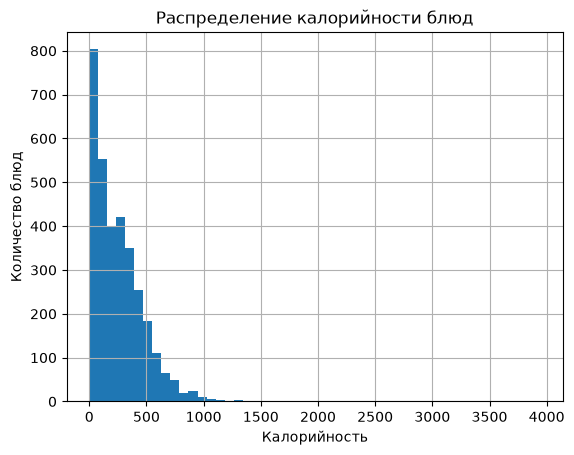

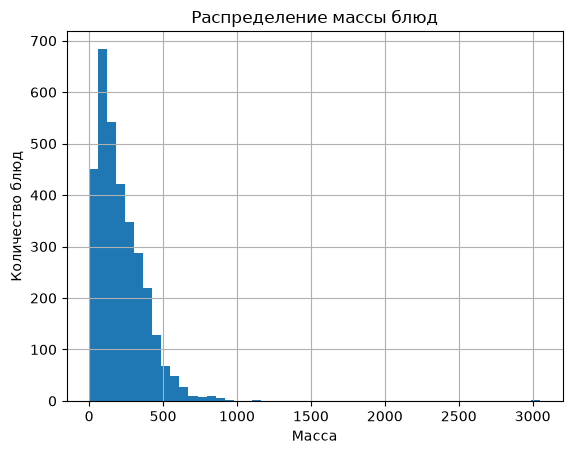

In [66]:
dish_df["total_calories"].hist(bins=50)
plt.title("Распределение калорийности блюд")
plt.xlabel("Калорийность")
plt.ylabel("Количество блюд")
plt.show()

dish_df["total_mass"].hist(bins=50)
plt.title("Распределение массы блюд")
plt.xlabel("Масса")
plt.ylabel("Количество блюд")
plt.show()

Оба распределения имеют относиительно средней длины правый хваост. 

Большинство блюд имеет относительно небольшую массу и каллорийность, но в датасете встречаются отдельные очень большие значения.

На этом этапе не будем считать их ошибками или удалять из данных. Сначала посмотрим на блюда с самыми большими значениями, а также отдельно проверим блюда с нулевой каллорийностью.

In [67]:
display(
    dish_df.nlargest(5, "total_calories")[
        ["dish_id", "total_calories", "total_mass", "ingredients", "split"]
    ]
)

display(
    dish_df.nlargest(5, "total_mass")[
        ["dish_id", "total_calories", "total_mass", "ingredients", "split"]
    ]
)

display(
    dish_df[dish_df["total_calories"] == 0]
)

,dish_id,total_calories,total_mass,ingredients,split
1518,dish_1560974769,3943.325195,3051.0,ingr_0000000036;ingr_0000000251;ingr_000000004...,train
124,dish_1565033265,1324.084961,625.0,ingr_0000000012;ingr_0000000029;ingr_000000002...,train
2753,dish_1562603895,1268.157349,517.0,ingr_0000000041;ingr_0000000029;ingr_000000033...,train
1125,dish_1564170010,1264.548340,831.0,ingr_0000000060;ingr_0000000031;ingr_000000052...,train
1951,dish_1563476577,1238.033691,857.0,ingr_0000000025;ingr_0000000027;ingr_000000013...,train


,dish_id,total_calories,total_mass,ingredients,split
1518,dish_1560974769,3943.325195,3051.0,ingr_0000000036;ingr_0000000251;ingr_000000004...,train
328,dish_1561739805,696.363525,1102.0,ingr_0000000040;ingr_0000000027;ingr_000000001...,train
2321,dish_1564590352,497.915833,962.0,ingr_0000000038;ingr_0000000037;ingr_000000047...,train
3007,dish_1561739760,452.163513,937.0,ingr_0000000338;ingr_0000000294;ingr_000000004...,train
2838,dish_1563305083,1234.856323,901.0,ingr_0000000203;ingr_0000000030;ingr_000000013...,train


,dish_id,total_calories,total_mass,ingredients,split
263,dish_1557861216,0.0,1.0,ingr_0000000423,test
2652,dish_1556575700,0.0,86.0,ingr_0000000423,train


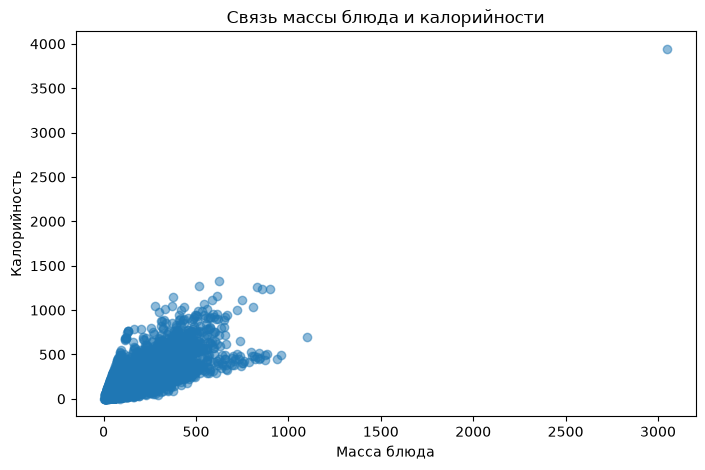

In [90]:
plt.figure(figsize=(8, 5))

plt.scatter(
    dish_df["total_mass"],
    dish_df["total_calories"],
    alpha=0.5
)

plt.xlabel("Масса блюда")
plt.ylabel("Калорийность")
plt.title("Связь массы блюда и калорийности")
plt.show()

Ага, самое калорийное блюдо одновременно имеет и самую большую массу 3051 г. Это вполне себе логично и нормально и удалять такие наблюдения как выбросы без дополнительных оснований не будем, но стандартизивировать возможно нужно будет.

Также обнаружено два блюда с нулевой калорийностью. Оба содержат один и тот же ингрнедиент, поэтому проверим его название.

In [68]:
ingredients_df[ingredients_df["id"] == 423]

,id,ingr
422,423,plate only


Эммм, честно говоря, без бизнес аналитика, я даже и не знаю как бы правильно это интеррпретировать. Ингредиент `ingr_0000000423` -> `plate only`, то есть на фотке будет буквально пустая тарелка. И вот тут вопрос, конечно, стоит ли удалять такое, но пожалуй оставим. По крайне мере, нулевая каллорийность этих двух наблюденний выглядит корректно.

Теперь, давайте всё же приведём названия ингредиентов к человеческому видду.

In [69]:
ingredient_map = dict(zip(
    ingredients_df["id"],
    ingredients_df["ingr"]
))

In [70]:
def replace_ingredient_ids(ingredients):
    ingredient_ids = ingredients.split(";")
    ingredient_names = []

    for ingredient_id in ingredient_ids:
        ingredient_id = int(ingredient_id.replace("ingr_", ""))
        ingredient_names.append(ingredient_map[ingredient_id])

    return ", ".join(ingredient_names)

In [71]:
dish_df["ingredients"] = dish_df["ingredients"].apply(replace_ingredient_ids)

dish_df[["dish_id", "ingredients"]].head()

,dish_id,ingredients
0,dish_1561662216,"soy sauce, garlic, white rice, parsley, onions..."
1,dish_1561662054,"pepper, white rice, mixed greens, garlic, soy ..."
2,dish_1562008979,"jalapenos, lemon juice, pork, wheat berry, cab..."
3,dish_1560455030,"cherry tomatoes, cucumbers, baby carrots"
4,dish_1558372433,deprecated


Теперь столбец `ingredients` содержит обычный текст с составом блюда. В таком виде его можно будет передавать в текстовый энкодер модели.

Также, давайте посмотрим на фотки блюд.

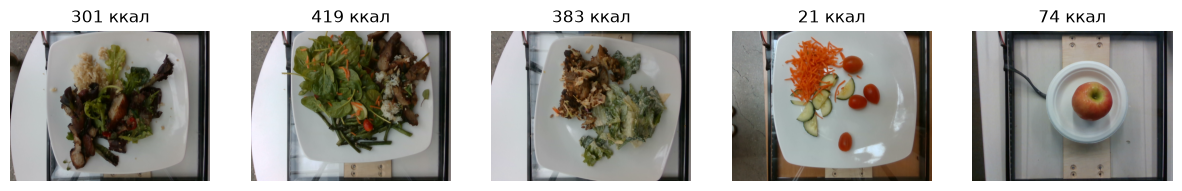

In [72]:
sample = dish_df.head(5)

plt.figure(figsize=(15, 4))

for i, row in enumerate(sample.itertuples()):
    img_path = os.path.join(
        IMAGES_DIR,
        str(row.dish_id),
        "rgb.png"
    )

    image = Image.open(img_path).convert("RGB")

    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title(f"{row.total_calories:.0f} ккал")
    plt.axis("off")

plt.show()

Итак, можно сказать, что теперь для каждого блюда мы имеем по два основных источника информации для модели, это изображение и текст с составом блюда. Шикарно!

Однако ещё пожалуй, стоит проверить, что мы имеем ВСЕ нужные фотки.

In [73]:
missing_images = []

for dish_id in dish_df["dish_id"]:
    img_path = os.path.join(IMAGES_DIR, str(dish_id), "rgb.png")

    if not os.path.exists(img_path):
        missing_images.append(dish_id)

print("Количество блюд без изображения:", len(missing_images))

Количество блюд без изображения: 0


Отлично!

### Выводы по EDA

В датасете содержится 3262 блюда: 2755 объектов относятся к обучающей выборке и 507 к тестовой. Пропущенных значений, полных дубликатов и отсутствующих изображений, слава богу, не обнаружено.

Целевая переменная total_calories имеет нераавномерное распределение с правым хвостом. Аналоргичная ситуация наблюдается и для массы блюд.

При этом крайние значения имеют логичное объяснение, поэтому удалять их из данных не будем.

Идентификаторы ингредиентов были заменены на норм названия продуктов. Теперь для каждого блюда доступны фотки и текст состава.

Для решения задачи будем использовать мультимодальную нейронную сеть:
- предобученную модель для получения признаков изображения;
- предобученную текстовую модель для обработки списка ингредиентов;
- проекционные слои для приведения признаков к одлинаковой размерности;
- объединение признаков изображения и текста;
- регрессионный слой с одним выходом для предсказания калорийности.

Для обучающей выборки, абсолютно не лишним будет, применить небольшую аугментацию изображений. Для тестовой выборки будем использовать только необходимые преобразованния без случайных аугментаций, так как по факту там гораздо сложнее нагенерить доп примеры ну или данные ддля обучения без использования сторонней ллмки.

В качестве функции потерь и основной метрики будем использовать MAE, как я определил ещё в начале проекта, так как задача является регрессией.

## 3. Подготовка данных для обучения

После EDA датасет. Основную логику вынесем в скрипты, как вы и порекомендовали, чтобы обучение модели можно было воспроизвести повторным запуском отдельно.

*делаю файлик dataset.py*

Для работы с изображениями и текстом я сделал класс MultimodalDataset. 

Он по сути грузит фотку нужную, его списочек ингредиентов и таргет.

In [74]:
from scripts.dataset import MultimodalDataset, get_transforms

IMAGE_MODEL_NAME = "resnet50"

train_df = dish_df[dish_df["split"] == "train"].reset_index(drop=True)
test_df = dish_df[dish_df["split"] == "test"].reset_index(drop=True)

train_transforms = get_transforms(IMAGE_MODEL_NAME, ds_type="train")
test_transforms = get_transforms(IMAGE_MODEL_NAME, ds_type="test")

train_dataset = MultimodalDataset(train_df, train_transforms)
test_dataset = MultimodalDataset(test_df, test_transforms)

print("Train:", len(train_dataset))
print("Test:", len(test_dataset))

Train: 2755
Test: 507


In [75]:
sample = train_dataset[0]

print("Текст:", sample["text"])
print("Target:", sample["target"])
print("Размер изображения:", sample["image"].shape)

Текст: pepper, white rice, mixed greens, garlic, soy sauce, millet, lemon juice, bok choy, olive oil, onions, vinegar, green beans, pork, apple, sugar, salt, parsley
Target: 419.438782
Размер изображения: torch.Size([3, 224, 224])


Отлично! Всё работает!

## 4. Конфигурация модели

Основные параметры обучения вынесем в отдельную конфигурацию.

In [76]:
class Config:
    TEXT_MODEL_NAME = "bert-base-uncased"
    IMAGE_MODEL_NAME = "resnet50"

    BATCH_SIZE = 4
    EPOCHS = 20

    TEXT_LR = 3e-5
    IMAGE_LR = 1e-4
    CLASSIFIER_LR = 5e-4

    HIDDEN_DIM = 256
    DROPOUT = 0.15

    SEED = 42
    SAVE_PATH = "best_model.pth"    

## 5. Архитектура модели

Для предсказания калорийности будем использовать фотографию блюда и список его ингредиентов.

Модель отдельно отработает изображение и текст, объединит полученную информацию и на её основе предскажет калорийность блюда.



*создаём файлик utils*

In [77]:
from scripts.utils import MultimodalModel

model = MultimodalModel(Config)

print(model)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MultimodalModel(
  (text_model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-

Модель создана. Для работы с текстом, как вы ранее могли понять из 4 пункта, используем берту, а для изображений resnet50. Модели брал прямо из уроков по "Практика: мультимодальная нейросеть".

Теперь проверим модель на нескольких блюдах из датасета. Главное получить таргет.

In [78]:
from scripts.dataset import collate_fn

tokenizer = AutoTokenizer.from_pretrained(Config.TEXT_MODEL_NAME)

train_loader = DataLoader(
    train_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=False,
    collate_fn=partial(collate_fn, tokenizer=tokenizer)
)

batch = next(iter(train_loader))

with torch.no_grad():
    predictions = model(
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"],
        image=batch["image"]
    )

print("Размер батча:", batch["image"].shape)
print("Размер предсказаний:", predictions.shape)
print("Предсказания:", predictions)

Размер батча: torch.Size([4, 3, 224, 224])
Размер предсказаний: torch.Size([4, 1])
Предсказания: tensor([[1.0939],
        [1.1094],
        [1.2325],
        [0.8251]])


Проверили модель на небольшом батче из 4 блюд. Моделька норм принимает фотки и список ингредиентов и для каждого блюда возвращает таргет.

Пока предсказания далеки от реальной калл конечно, что логично, ведь модель мы ещё не обучали. Главное на этом этапе, что вся связка работает корректно и можно переходить к обучению.

## 6. Обучение модели

Перед обучением разделим обучающую выборку, чтобы получить validation часть.

На train данных будем обучать модельку, а на validation будем смотреть после каждой эпохи, чтобы видет, становится ли модель лучше.

In [79]:
val_df = train_df.sample(
    frac=0.15,
    random_state=Config.SEED
)

train_df = train_df.drop(val_df.index).reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 2342
Validation: 413
Test: 507


Теперь подготовим train и validation для обучения модели.

Для train оставим аугментацию, а для validation это ведь и не надо вовсе. По крайне мере, я посовещался с нейронкой и она мне сказала, что это вообще бессмысленное действие тут.

In [80]:
train_transforms = get_transforms(
    Config.IMAGE_MODEL_NAME,
    ds_type="train"
)

val_transforms = get_transforms(
    Config.IMAGE_MODEL_NAME,
    ds_type="test"
)

train_dataset = MultimodalDataset(
    train_df,
    train_transforms
)

val_dataset = MultimodalDataset(
    val_df,
    val_transforms
)

train_loader = DataLoader(
    train_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=True,
    collate_fn=partial(collate_fn, tokenizer=tokenizer)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=False,
    collate_fn=partial(collate_fn, tokenizer=tokenizer)
)

print("Train батчей:", len(train_loader))
print("Validation батчей:", len(val_loader))

Train батчей: 586
Validation батчей: 104


Данные для обучения готовы. Получили 586 батчей для train и 104 батча для validation.

Теперь можно переходить непосредственно к обучению модели.

*ддополняем файлик utils*

Теперь всё готово к обучению модели.

Будем обучать модель на train и после каждой эпохи смотреть MAE на validation.

In [81]:
from scripts.utils import train_model

device = torch.device("cuda")

model = MultimodalModel(Config)

model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    config=Config,
    device=device
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/20 | Train MAE: 236.73 | Val MAE: 227.67
Epoch 2/20 | Train MAE: 206.96 | Val MAE: 198.81
Epoch 3/20 | Train MAE: 180.42 | Val MAE: 166.31
Epoch 4/20 | Train MAE: 155.98 | Val MAE: 142.61
Epoch 5/20 | Train MAE: 137.80 | Val MAE: 131.48
Epoch 6/20 | Train MAE: 124.25 | Val MAE: 108.47
Epoch 7/20 | Train MAE: 112.33 | Val MAE: 100.80
Epoch 8/20 | Train MAE: 101.38 | Val MAE: 98.44
Epoch 9/20 | Train MAE: 95.09 | Val MAE: 87.85
Epoch 10/20 | Train MAE: 90.81 | Val MAE: 95.77
Epoch 11/20 | Train MAE: 87.01 | Val MAE: 82.64
Epoch 12/20 | Train MAE: 84.95 | Val MAE: 82.39
Epoch 13/20 | Train MAE: 79.86 | Val MAE: 79.89
Epoch 14/20 | Train MAE: 76.82 | Val MAE: 77.89
Epoch 15/20 | Train MAE: 73.88 | Val MAE: 77.83
Epoch 16/20 | Train MAE: 71.19 | Val MAE: 76.29
Epoch 17/20 | Train MAE: 70.31 | Val MAE: 77.35
Epoch 18/20 | Train MAE: 69.54 | Val MAE: 73.71
Epoch 19/20 | Train MAE: 67.19 | Val MAE: 69.01
Epoch 20/20 | Train MAE: 64.08 | Val MAE: 74.43


Обучение проводилось в течение 20 эпох. За это время MAE на validation уменьшилась с 227.67 до 69.01.

Лучший результат получился на 19-й эпохе. На 20-й эпохе MAE немного выросла, поэтому для дальнейшей проверки будем использовать сохранённую модель с лучшим результатом на validation.

## 7. Оценка модели на тестовой выборке

Обучение закончено, теперь проверим лучшую сохранённую модель на test.

Эти данные не использовались при обучении и validation, поэтому полученный MAE будем считать итоговым результатом модели.

In [86]:
test_transforms = get_transforms(
    Config.IMAGE_MODEL_NAME,
    ds_type="test"
)

test_dataset = MultimodalDataset(
    test_df,
    test_transforms
)

test_loader = DataLoader(
    test_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=False,
    collate_fn=partial(collate_fn, tokenizer=tokenizer)
)

model.load_state_dict(
    torch.load(Config.SAVE_PATH, map_location=device)
)

model = model.to(device)
model.eval()

MultimodalModel(
  (text_model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-

In [87]:
test_mae = 0

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        images = batch["image"].to(device)
        targets = batch["target"].to(device)

        predictions = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            image=images
        ).squeeze(1)

        test_mae += torch.abs(
            predictions - targets
        ).sum().item()

test_mae /= len(test_dataset)

print(f"Test MAE: {test_mae:.2f}")

Test MAE: 78.99


На тестовой выборке получили MAE = 78.99. То есть в среднем модель ошибается примерно на 79 ккал.

Результат немного хуже, чем лучший MAE на validation (69.01), но значения достаточно близкие.

В целом, я доволен итогами обучения модельки. По мере увеличения количества эпох ошибка заметно снижалась, а итоговое качество на тестовой выборке получилось значительно лучше, чем после первых эпох.

## 8. Анализ ошибок

Теперь посмотрим на блюда, где модель ошибается сильнее всего.

Для этого посчитаем ошибку отдельно для каждого блюда из test и выберем 5 самых неудачных предсказаний.

In [88]:
all_predictions = []
all_targets = []

model.eval()

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        images = batch["image"].to(device)

        predictions = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            image=images
        ).squeeze(1)

        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(batch["target"].numpy())


results_df = test_df.copy()

results_df["prediction"] = all_predictions
results_df["error"] = np.abs(
    results_df["total_calories"] - results_df["prediction"]
)

worst_5 = results_df.nlargest(5, "error")

worst_5[
    ["dish_id", "total_calories", "prediction", "error"]
]

,dish_id,total_calories,prediction,error
141,dish_1565811139,902.200012,323.199646,579.000366
479,dish_1558375886,1050.511108,500.599152,549.911956
54,dish_1558373159,1013.337036,467.700195,545.636841
354,dish_1566414412,920.120422,383.785645,536.334777
302,dish_1565030391,609.333923,87.727486,521.606437


Получили 5 блюд, на которых модель ошиблась сильнее всего.

Во всех пяти случаях модель занизила реальную калорийность блюда. Самая большая ошибка получилась на блюде с реальной калорийностью 902 ккал, а моделька предсказала около 323.

Можем посмотреть фотки и попробовать дать обхъяснение хоть какое-то.

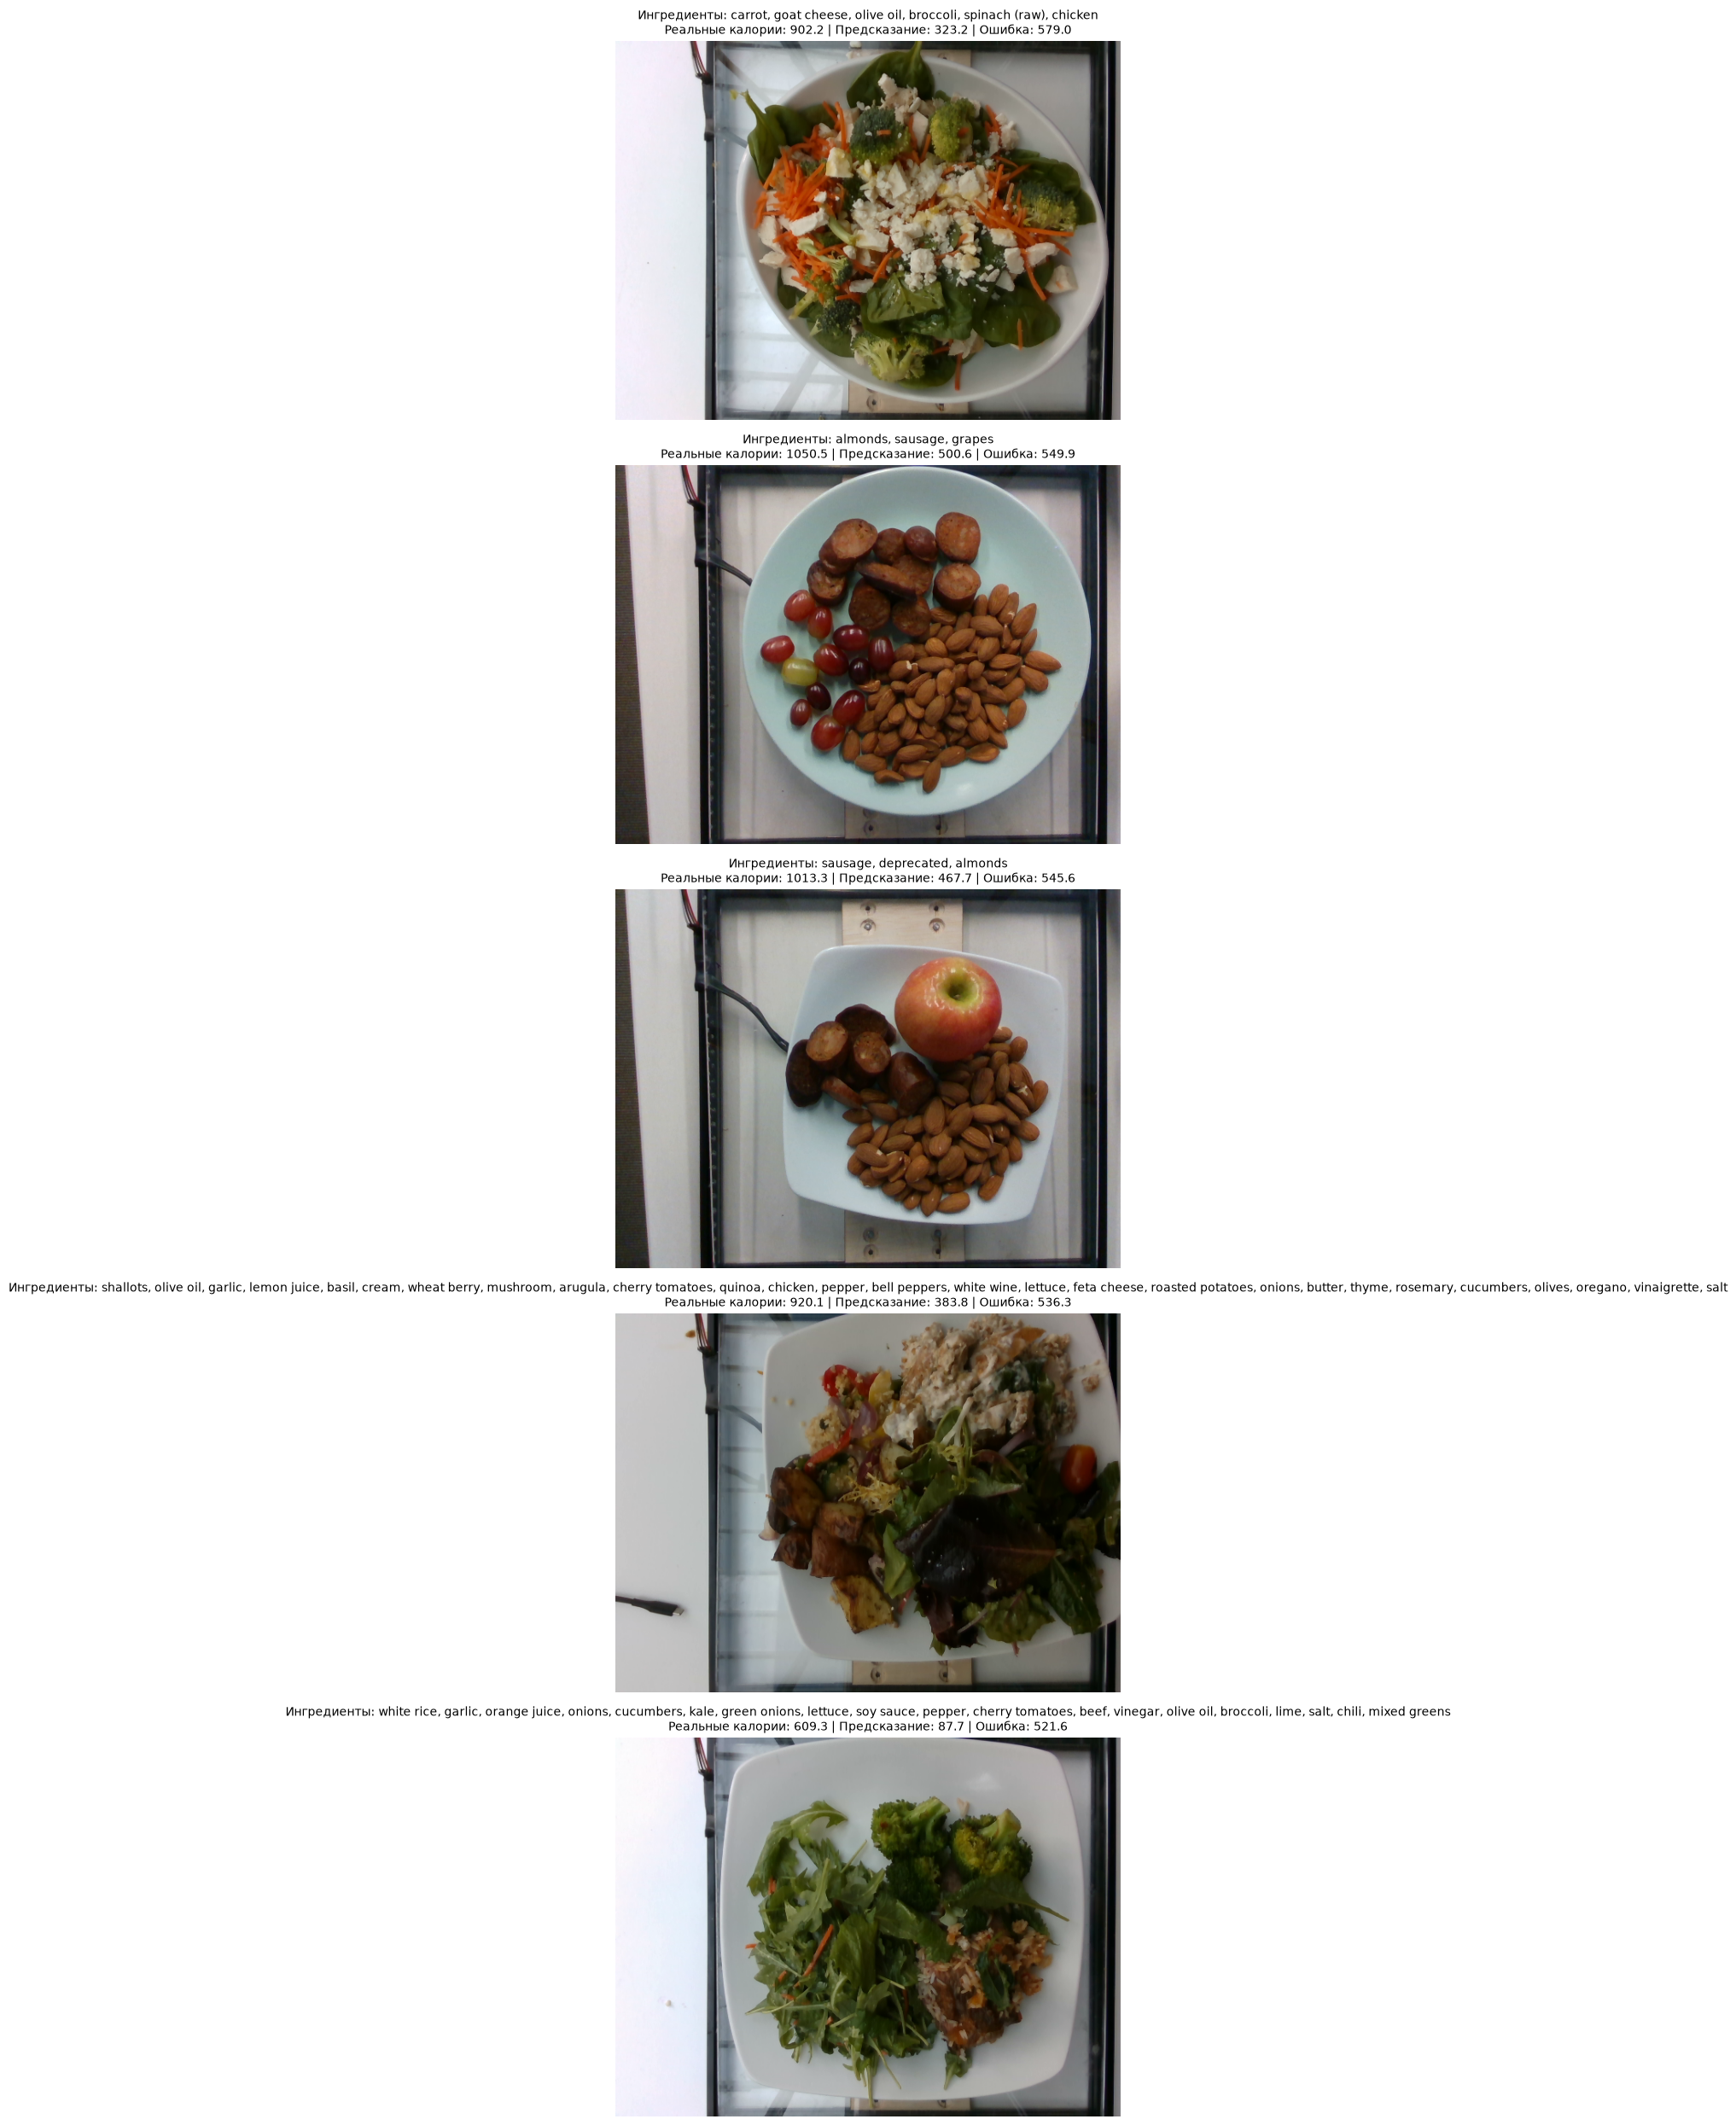

In [89]:
fig, axes = plt.subplots(
    5,
    1,
    figsize=(10, 25)
)

for ax, (_, row) in zip(axes, worst_5.iterrows()):
    img_path = os.path.join(
        IMAGES_DIR,
        str(row["dish_id"]),
        "rgb.png"
    )

    image = Image.open(img_path).convert("RGB")

    ax.imshow(image)
    ax.axis("off")

    ax.set_title(
        f'Ингредиенты: {row["ingredients"]}\n'
        f'Реальные калории: {row["total_calories"]:.1f} | '
        f'Предсказание: {row["prediction"]:.1f} | '
        f'Ошибка: {row["error"]:.1f}',
        fontsize=10
    )

plt.tight_layout()
plt.show()

По фотографиям видно, что самые большие ошибки возникают на достаточно сложных блюдах, где одновременно присутствует много разных продуктов.

Например, на фотографиях с орехами, колбаской и фруктами модели нужно не только определить сами продукты, но и понять их количество, цвет, объём. Это особенно важно для орехов, потому что даже визуально небольшая порция может сильно влиять на общую калорийность блюда.

Похожая проблема видна и на салатах. В них много ингредиентов перемешаны между собой, часть продуктов перекрывает другие, а на фотографии преобладают именно зелёные оттенки. Из-за этого по изображению сложно точно разделить отдельные продукты и оценить их количество.

Также во всех пяти худших примерах модель занижает калорийность. Это может говорить о том, что модельке сложно понять, что масса блюда не всегда может коллерировать с каллийронстью блюда, так например орехи могут быть хоть и в маленьком количестве и иметь малую массу, но их калл крайне высока...

В общем то,, для дальнейшего улучшения модели можно попробовать добавить массу именно уже ингредиентов, это кажется гениальная идея. Ну и конечно, можно провести больше экспериментов с обучением и отдельно проверить влияние аугментаций изображений.

## 9. Итоговый вывод

Итак, в этом проекте я обучил модель для предсказания калорийности блюда по фотографии и списку ингредиентов. 

Текст и изображение у нас обрабатываются отдельно с помощью моделек bert и resnet50, после чего полученные признаки аккумулируются, ну или объединяются и используются для предсказания калорийности.

Модель обучалась 20 эпох. За это время MAE на validation уменьшилась с 227.67 до 69.01. Лучший результат был получен на 19-й эпохе. На тестовой выборке итоговый MAE составил 78.99 ккал.

При анализе самых больших ошибок оказалось, что во всех пяти случаях модель заметно занижала калорийность. В основном это были блюда с большим количеством разных ингредиентов или продукты, для которых по фотографии сложно определить их каллорийность.

В дальнейшем модель можно попробовать улучшить, добавив массу ингредиентов по отедельности как отдельные признаки, продолжив эксперименты с обучением и отдельно проверив влияние аугментаций.

В итоге удалось собрать полный рабочий пайплайн! От подготовки данных и изображений до обучения модели, проверки на тестовой выборке и анализа отдельных ошибок. Результатом работы я доволен.